In [137]:
# IMPORTS
import os
import cv2
import numpy as np
import pandas as pd
import pickle

from skimage.feature import graycomatrix, graycoprops

from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Input, Concatenate
from tensorflow.keras.optimizers import Adam

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, cohen_kappa_score, log_loss, confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# VGG16 FEATURE EXTRACTOR
def build_vgg16():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
    return Model(inputs=base_model.input, outputs=base_model.output)


# RESNET50 FEATURE EXTRACTOR
def build_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    return Model(inputs=base_model.input, outputs=base_model.output)

In [75]:
# GLCM FEATURE EXTRACTION
def extract_glcm_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return [contrast, energy, homogeneity]

In [76]:
# IMAGE FEATURE EXTRACTION PIPELINE
def extract_features(image_path, vgg_model):
    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (224, 224))

    # VGG features
    img_array = preprocess_input(np.expand_dims(img_resized, axis=0))
    vgg_features = vgg_model.predict(img_array, verbose=0)[0]

    # GLCM features
    glcm_features = extract_glcm_features(img)

    return vgg_features, glcm_features

In [77]:
# CREATE CSV DATASET
def create_feature_csv(dataset_path, output_csv):
    vgg_model = build_resnet50() # build_vgg16()

    data = []

    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            vgg_feat, glcm_feat = extract_features(img_path, vgg_model)

            row = list(vgg_feat) + list(glcm_feat) + [class_name, img_path]
            data.append(row)

    columns = [f'vgg_{i}' for i in range(len(vgg_feat))] + \
              ['contrast', 'energy', 'homogeneity', 'label', 'path']

    df = pd.DataFrame(data, columns=columns)
    df.to_csv(output_csv, index=False)

    return df

In [78]:
# CONDITIONAL GAN

# Generator
def build_generator(input_dim, condition_dim):
    input_feat = Input(shape=(input_dim,))
    condition = Input(shape=(condition_dim,))

    x = Concatenate()([input_feat, condition])
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(input_dim)(x)

    return Model([input_feat, condition], output)


# Discriminator
def build_discriminator(input_dim):
    inp = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inp)
    x = Dense(64, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))

    return model



In [79]:
# TRAIN GAN
def train_gan(X_vgg, X_glcm, epochs=1000):
    gen = build_generator(X_vgg.shape[1], X_glcm.shape[1])
    disc = build_discriminator(X_vgg.shape[1])

    for epoch in range(epochs):
        idx = np.random.randint(0, X_vgg.shape[0], 32)

        real = X_vgg[idx]
        cond = X_glcm[idx]

        fake = gen.predict([real, cond], verbose=0)

        disc.train_on_batch(real, np.ones((32, 1)))
        disc.train_on_batch(fake, np.zeros((32, 1)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch}")

    return gen

In [80]:
# GENERATE FEATURES & SAVE CSV
def generate_features_csv(generator, df, output_csv):
    vgg_cols = [col for col in df.columns if 'vgg_' in col]
    glcm_cols = ['contrast', 'energy', 'homogeneity']

    X_vgg = df[vgg_cols].values
    X_glcm = df[glcm_cols].values

    generated = generator.predict([X_vgg, X_glcm])

    new_df = pd.DataFrame(generated, columns=vgg_cols)
    new_df['label'] = df['label']

    new_df.to_csv(output_csv, index=False)

In [81]:
# TRAIN CLASSIFIER
def train_classifier(df):
    X = df.drop(['label', 'path'], axis=1, errors='ignore')
    y = df['label']

    model = RandomForestClassifier()
    model.fit(X, y)

    return model

In [102]:
# EVALUATION
def evaluate_model(model, df):
    X = df.drop(['label', 'path'], axis=1, errors='ignore')
    y = df['label']

    preds = model.predict(X)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y, preds)

    # For loss (log loss/cross-entropy loss)
    # Note: log_loss works with probabilities
    loss = 1 - accuracy # log_loss(y, preds)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(y, preds)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Loss (Log Loss): {loss:.4f}")
    print(f"Cohen's Kappa Score: {kappa:.4f}")
    print("\nClassification Report:")
    print(classification_report(y, preds))
    
# ADD MORE MATRICS HERE 


In [83]:
# SAVE MODELS
def save_models(vgg_model, generator, classifier):
    vgg_model.save("vgg_model.h5")
    generator.save("generator.h5")

    with open("classifier.pkl", "wb") as f:
        pickle.dump(classifier, f)

In [84]:
# FINAL PREDICTION PIPELINE
def predict_image(image_path):
    vgg = load_model("vgg_model.h5")
    gen = load_model("generator.h5")

    with open("classifier.pkl", "rb") as f:
        clf = pickle.load(f)

    vgg_feat, glcm_feat = extract_features(image_path, vgg)

    gen_feat = gen.predict([np.array([vgg_feat]), np.array([glcm_feat])])

    pred = clf.predict(gen_feat)

    return pred

In [85]:
# # MAIN FUNCTION
# # def main():
#     # ==============================
#     # PATH CONFIG
#     # ==============================
#     dataset_path = os.path.join('awa_data', 'train') # your dataset
#     real_csv = "real_features.csv"
#     fake_csv = "generated_features.csv"
#     test_image = os.path.join('awa_data', 'test', 'bobcat', 'bobcat_10069.jpg') # change this

#     # ==============================
#     # STEP 1: CREATE DATASET CSV
#     # ==============================
#     print("Step 1: Extracting features...")
#     df_real = create_feature_csv(dataset_path, real_csv)

#     # ==============================
#     # STEP 2: PREPARE DATA
#     # ==============================
#     print("Step 2: Preparing data...")

#     vgg_cols = [col for col in df_real.columns if 'vgg_' in col]
#     glcm_cols = ['contrast', 'energy', 'homogeneity']

#     X_vgg = df_real[vgg_cols].values
#     X_glcm = df_real[glcm_cols].values

#     # ==============================
#     # STEP 3: TRAIN GAN
#     # ==============================
#     print("Step 3: Training GAN...")
#     generator = train_gan(X_vgg, X_glcm, epochs=500)

#     # ==============================
#     # STEP 4: GENERATE FEATURES
#     # ==============================
#     print("Step 4: Generating synthetic features...")
#     generate_features_csv(generator, df_real, fake_csv)

#     df_fake = pd.read_csv(fake_csv)

#     # ==============================
#     # STEP 5: COMBINE DATA
#     # ==============================
#     print("Step 5: Combining datasets...")
#     df_combined = pd.concat([df_real.drop(columns=['path']), df_fake], ignore_index=True)

# #     # ==============================
# #     # STEP 6: TRAIN CLASSIFIER
# #     # ==============================
# #     print("Step 6: Training classifier...")
# #     classifier = train_classifier(df_combined)

# #     # ==============================
# #     # STEP 7: EVALUATE
# #     # ==============================
# #     print("Step 7: Evaluating model...")
# #     evaluate_model(classifier, df_combined)

# #     # ==============================
# #     # STEP 8: SAVE MODELS
# #     # ==============================
# #     print("Step 8: Saving models...")
# #     vgg_model = build_vgg16()
# #     save_models(vgg_model, generator, classifier)

# #     # ==============================
# #     # STEP 9: TEST PREDICTION
# #     # ==============================
# #     print("Step 9: Testing prediction...")
# #     result = predict_image(test_image)

# #     print("Prediction:", result)
    
    
# # RUN THIS
# if __name__ == "__main__":
#     main()

In [86]:

# ==============================
# PATH CONFIG
# ==============================
dataset_path = os.path.join('awa_data', 'train') # your dataset
real_csv = "real_features.csv"
fake_csv = "generated_features.csv"
test_image = os.path.join('awa_data', 'test', 'bobcat', 'bobcat_10069.jpg') # change this

# ==============================
# STEP 1: CREATE DATASET CSV
# ==============================
print("Step 1: Extracting features...")
df_real = create_feature_csv(dataset_path, real_csv)
display(df_real.head())

Step 1: Extracting features...


,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,vgg_9,...,vgg_2043,vgg_2044,vgg_2045,vgg_2046,vgg_2047,contrast,energy,homogeneity,label,path
0,0.169566,0.443888,0.038033,0.323292,0.186861,2.061228,0.318309,0.191118,0.269263,0.464712,...,0.149682,0.417985,0.000000,0.000000,0.035190,155.988680,0.030120,0.297338,bear,awa_data\train\bear\bear_10001 (1).jpg
1,0.250307,1.578907,0.049122,0.384802,0.420536,2.103792,0.000000,0.339524,0.106223,0.229243,...,0.071920,0.630635,1.535823,0.027992,0.054443,12.505955,0.052245,0.556446,bear,awa_data\train\bear\bear_10001 (10).jpg
2,0.042560,0.655144,0.040753,0.098268,0.270316,1.218815,0.107444,1.415878,0.411815,0.849117,...,0.334281,0.038379,0.030033,0.072438,0.000000,21.364139,0.034127,0.482136,bear,awa_data\train\bear\bear_10001 (11).jpg
3,0.098225,1.616208,0.166989,0.410855,0.069630,2.985137,0.048280,0.246293,0.544231,0.274829,...,0.048215,0.079272,0.017580,0.298425,0.007066,108.480442,0.017138,0.216688,bear,awa_data\train\bear\bear_10001 (12).jpg
4,0.037237,1.071350,0.037793,0.000000,0.000000,0.738029,0.000000,0.186785,0.169007,0.539413,...,0.189057,0.036734,0.124710,0.020877,0.018643,40.158139,0.020727,0.289240,bear,awa_data\train\bear\bear_10001 (13).jpg


In [87]:

# ==============================
# STEP 2: PREPARE DATA
# ==============================
print("Step 2: Preparing data...")

vgg_cols = [col for col in df_real.columns if 'vgg_' in col]
glcm_cols = ['contrast', 'energy', 'homogeneity']

X_vgg = df_real[vgg_cols].values
X_glcm = df_real[glcm_cols].values

Step 2: Preparing data...


In [88]:

# ==============================
# STEP 3: TRAIN GAN
# ==============================
print("Step 3: Training GAN...")
generator = train_gan(X_vgg, X_glcm, epochs=500)
print(f"generator : {generator}")

Step 3: Training GAN...
Epoch 0
Epoch 100
Epoch 200
Epoch 300
Epoch 400
generator : <keras.src.engine.functional.Functional object at 0x00000229EB5807C0>


In [89]:

# ==============================
# STEP 4: GENERATE FEATURES
# ==============================
print("Step 4: Generating synthetic features...")
generate_features_csv(generator, df_real, fake_csv)

df_fake = pd.read_csv(fake_csv)
display(df_fake.head())

Step 4: Generating synthetic features...
23/23 [==============================] - 0s 6ms/step


,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,vgg_9,...,vgg_2039,vgg_2040,vgg_2041,vgg_2042,vgg_2043,vgg_2044,vgg_2045,vgg_2046,vgg_2047,label
0,0.070276,1.117948,0.304108,0.106464,0.015786,-0.109053,0.561747,1.198083,1.320946,0.647905,...,-0.681151,0.833208,-0.459416,0.292004,0.449065,-1.487299,-0.701607,0.600908,-1.337643,bear
1,-0.247020,-0.143332,0.074554,0.084303,0.007921,-0.121367,0.208418,0.401509,0.397418,0.232348,...,0.072400,0.296530,0.030731,0.159513,-0.018441,-0.324010,-0.105902,0.244523,-0.279153,bear
2,-0.112497,0.107482,0.179103,-0.069640,-0.103934,-0.007367,0.496128,0.586818,0.447280,0.526215,...,0.041579,0.259921,-0.098066,0.205150,-0.073647,-0.374779,-0.263245,0.382759,-0.333213,bear
3,-0.096109,0.745223,0.355779,0.287739,-0.012150,0.023461,0.507485,0.984344,0.946011,0.409328,...,-0.392161,0.380536,-0.274709,0.466542,0.365022,-1.018138,-0.669737,0.364079,-0.819850,bear
4,0.029767,0.264470,0.079032,-0.011113,0.010274,0.175383,0.404378,0.735496,0.488750,0.401174,...,-0.225428,0.376785,-0.029161,0.283632,0.181637,-0.330901,-0.322379,0.340470,-0.736939,bear


In [90]:
df_real.head()

,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,vgg_9,...,vgg_2043,vgg_2044,vgg_2045,vgg_2046,vgg_2047,contrast,energy,homogeneity,label,path
0,0.169566,0.443888,0.038033,0.323292,0.186861,2.061228,0.318309,0.191118,0.269263,0.464712,...,0.149682,0.417985,0.000000,0.000000,0.035190,155.988680,0.030120,0.297338,bear,awa_data\train\bear\bear_10001 (1).jpg
1,0.250307,1.578907,0.049122,0.384802,0.420536,2.103792,0.000000,0.339524,0.106223,0.229243,...,0.071920,0.630635,1.535823,0.027992,0.054443,12.505955,0.052245,0.556446,bear,awa_data\train\bear\bear_10001 (10).jpg
2,0.042560,0.655144,0.040753,0.098268,0.270316,1.218815,0.107444,1.415878,0.411815,0.849117,...,0.334281,0.038379,0.030033,0.072438,0.000000,21.364139,0.034127,0.482136,bear,awa_data\train\bear\bear_10001 (11).jpg
3,0.098225,1.616208,0.166989,0.410855,0.069630,2.985137,0.048280,0.246293,0.544231,0.274829,...,0.048215,0.079272,0.017580,0.298425,0.007066,108.480442,0.017138,0.216688,bear,awa_data\train\bear\bear_10001 (12).jpg
4,0.037237,1.071350,0.037793,0.000000,0.000000,0.738029,0.000000,0.186785,0.169007,0.539413,...,0.189057,0.036734,0.124710,0.020877,0.018643,40.158139,0.020727,0.289240,bear,awa_data\train\bear\bear_10001 (13).jpg


In [91]:
df_fake.head()

,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,vgg_9,...,vgg_2039,vgg_2040,vgg_2041,vgg_2042,vgg_2043,vgg_2044,vgg_2045,vgg_2046,vgg_2047,label
0,0.070276,1.117948,0.304108,0.106464,0.015786,-0.109053,0.561747,1.198083,1.320946,0.647905,...,-0.681151,0.833208,-0.459416,0.292004,0.449065,-1.487299,-0.701607,0.600908,-1.337643,bear
1,-0.247020,-0.143332,0.074554,0.084303,0.007921,-0.121367,0.208418,0.401509,0.397418,0.232348,...,0.072400,0.296530,0.030731,0.159513,-0.018441,-0.324010,-0.105902,0.244523,-0.279153,bear
2,-0.112497,0.107482,0.179103,-0.069640,-0.103934,-0.007367,0.496128,0.586818,0.447280,0.526215,...,0.041579,0.259921,-0.098066,0.205150,-0.073647,-0.374779,-0.263245,0.382759,-0.333213,bear
3,-0.096109,0.745223,0.355779,0.287739,-0.012150,0.023461,0.507485,0.984344,0.946011,0.409328,...,-0.392161,0.380536,-0.274709,0.466542,0.365022,-1.018138,-0.669737,0.364079,-0.819850,bear
4,0.029767,0.264470,0.079032,-0.011113,0.010274,0.175383,0.404378,0.735496,0.488750,0.401174,...,-0.225428,0.376785,-0.029161,0.283632,0.181637,-0.330901,-0.322379,0.340470,-0.736939,bear


In [92]:

# ==============================
# STEP 5: COMBINE DATA
# ==============================
print("Step 5: Combining datasets...")
df_combined = pd.concat([df_real.drop(columns=['contrast', 'energy', 'homogeneity', 'path']), df_fake], ignore_index=True)

# Drop rows with any NaN and reset index
# df_combined = df_combined.dropna().reset_index(drop=True)

display(df_combined.head())
# df_combined.isna().sum()

Step 5: Combining datasets...


,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,vgg_9,...,vgg_2039,vgg_2040,vgg_2041,vgg_2042,vgg_2043,vgg_2044,vgg_2045,vgg_2046,vgg_2047,label
0,0.169566,0.443888,0.038033,0.323292,0.186861,2.061228,0.318309,0.191118,0.269263,0.464712,...,0.741232,3.208643,0.400222,0.368099,0.149682,0.417985,0.000000,0.000000,0.035190,bear
1,0.250307,1.578907,0.049122,0.384802,0.420536,2.103792,0.000000,0.339524,0.106223,0.229243,...,0.000000,0.470463,0.036392,0.107110,0.071920,0.630635,1.535823,0.027992,0.054443,bear
2,0.042560,0.655144,0.040753,0.098268,0.270316,1.218815,0.107444,1.415878,0.411815,0.849117,...,0.000355,0.259965,0.143462,0.376420,0.334281,0.038379,0.030033,0.072438,0.000000,bear
3,0.098225,1.616208,0.166989,0.410855,0.069630,2.985137,0.048280,0.246293,0.544231,0.274829,...,0.260080,0.584257,0.394409,0.897789,0.048215,0.079272,0.017580,0.298425,0.007066,bear
4,0.037237,1.071350,0.037793,0.000000,0.000000,0.738029,0.000000,0.186785,0.169007,0.539413,...,0.000000,0.879503,0.000000,1.061292,0.189057,0.036734,0.124710,0.020877,0.018643,bear


In [103]:

# ==============================
# STEP 6: TRAIN CLASSIFIER
# ==============================
print("Step 6: Training classifier...")
classifier = train_classifier(df_combined)

# ==============================
# STEP 7: EVALUATE
# ==============================
print("Step 7: Evaluating model...")
evaluate_model(classifier, df_combined)

Step 6: Training classifier...
Step 7: Evaluating model...
Accuracy: 1.0000
Loss (Log Loss): 0.0000
Cohen's Kappa Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

        bear       1.00      1.00      1.00        80
  blue_whale       1.00      1.00      1.00        80
      bobcat       1.00      1.00      1.00        80
         cow       1.00      1.00      1.00        80
     dolphin       1.00      1.00      1.00        80
     gorilla       1.00      1.00      1.00        80
killer_whale       1.00      1.00      1.00        80
        lion       1.00      1.00      1.00        80
      monkey       1.00      1.00      1.00        80
       mouse       1.00      1.00      1.00        80
          ox       1.00      1.00      1.00        80
      rabbit       1.00      1.00      1.00        80
  rhinoceros       1.00      1.00      1.00        80
 siamese_cat       1.00      1.00      1.00        80
       skunk       1.00      1.00    

In [104]:

# ==============================
# STEP 8: SAVE MODELS
# ==============================
print("Step 8: Saving models...")
vgg_model = build_resnet50() # build_vgg16()
save_models(vgg_model, generator, classifier)

Step 8: Saving models...


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [105]:

# ==============================
# STEP 9: TEST PREDICTION
# ==============================
print("Step 9: Testing prediction...")
result = predict_image(test_image)

print("Prediction:", result)
    

Step 9: Testing prediction...
1/1 [==============================] - 0s 67ms/step
Prediction: ['bobcat']


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# unseen

In [108]:
import glob
import pandas as pd
import numpy as np

from skimage.feature import graycomatrix, graycoprops

from sentence_transformers import SentenceTransformer, util
import torch
# 1. SciBert - (pritamdeka/S-Scibert-snli-multinli-stsb)
# 2. BioBERT- (emilyalsentzer/Bio_ClinicalBERT)
# 3. Transformer model (all-MiniLM-L6-v2)
# 4. RoBERTa (sentence-transformers/all-roberta-large-v1)

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [117]:
def get_top_similar_classes_df(predicted_class,
                               sentence_model,
                               class_embeddings,
                               class_labels,
                               k=5):
    """
    Get top k similar classes and return them as a tuple of lists
    """
    # Encode the predicted class
    unseen_query = sentence_model.encode(predicted_class,
                                         convert_to_tensor=True)

    # Calculate cosine similarities
    unseen_cosine_scores = util.cos_sim(unseen_query,
                                        class_embeddings)
    unseen_top_results = torch.topk(unseen_cosine_scores[0],
                                    k=k)

    # Extract top class names and probabilities
    top_class_names = []
    top_probabilities = []
    for score, idx in zip(unseen_top_results.values,
                          unseen_top_results.indices):
        top_class_names.append(class_labels[idx])
        top_probabilities.append(float(f"{score:.2f}"))

    return top_class_names, top_probabilities


SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2', trust_remote_code=True)

seen_class_labels = ["bear", "blue_whale", "bobcat", "cow", "dolphin", "gorilla", 
                     "killer_whale", "lion", "monkey", "mouse", "ox", "rabbit", 
                     "rhinoceros", "siamese_cat", "skunk", "squirrel", "tiger", "walrus"]
seen_idx_to_class = {k: v for k, v in enumerate(seen_class_labels)}
seen_words = list(seen_idx_to_class.values())
seen_embeddings = SentenceTransformer_model.encode(seen_words, convert_to_tensor=True)
print(len(seen_embeddings))
print("="*60)

unseen_class_labels = ['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 
                       'persian_cat', 'pig', 'raccoon', 'rat', 'seal']
unseen_idx_to_class = {k: v for k, v in enumerate(unseen_class_labels)}
unseen_words = list(unseen_idx_to_class.values())
unseen_embeddings = SentenceTransformer_model.encode(unseen_words, convert_to_tensor=True)
print(len(unseen_embeddings))
print("="*60)

18
10


In [121]:
class_labels = sorted([path.split('\\')[-1] for path in glob.glob(os.path.join('awa_data', 'test', '*'))])
lables_dict = {k:v for k, v in enumerate(class_labels) }
class_dict = {v: k for k, v in lables_dict.items()}
print(class_labels)
print(lables_dict)
print(class_dict)

print("="*100)

unseen_class_labels = sorted([path.split('\\')[-1] for path in glob.glob(os.path.join('awa_data', 'unseen', '*'))])
unseen_lables_dict = {k:v for k, v in enumerate(unseen_class_labels) }
unseen_class_dict = {v: k for k, v in unseen_lables_dict.items()}
print(unseen_class_labels)
print(unseen_lables_dict)
print(unseen_class_dict)

['bear', 'blue_whale', 'bobcat', 'cow', 'dolphin', 'gorilla', 'killer_whale', 'lion', 'monkey', 'mouse', 'ox', 'rabbit', 'rhinoceros', 'siamese_cat', 'skunk', 'squirrel', 'tiger', 'walrus']
{0: 'bear', 1: 'blue_whale', 2: 'bobcat', 3: 'cow', 4: 'dolphin', 5: 'gorilla', 6: 'killer_whale', 7: 'lion', 8: 'monkey', 9: 'mouse', 10: 'ox', 11: 'rabbit', 12: 'rhinoceros', 13: 'siamese_cat', 14: 'skunk', 15: 'squirrel', 16: 'tiger', 17: 'walrus'}
{'bear': 0, 'blue_whale': 1, 'bobcat': 2, 'cow': 3, 'dolphin': 4, 'gorilla': 5, 'killer_whale': 6, 'lion': 7, 'monkey': 8, 'mouse': 9, 'ox': 10, 'rabbit': 11, 'rhinoceros': 12, 'siamese_cat': 13, 'skunk': 14, 'squirrel': 15, 'tiger': 16, 'walrus': 17}
['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal']
{0: 'chimpanzee', 1: 'giant_panda', 2: 'hippopotamus', 3: 'humpback_whale', 4: 'leopard', 5: 'persian_cat', 6: 'pig', 7: 'raccoon', 8: 'rat', 9: 'seal'}
{'chimpanzee': 0, 'giant_panda

In [131]:
image_paths, image_names, act_lables, top_seen_labels, top_unseen_labels = [], [], [], [], []
pred_labels, act_vals, pred_vals = [], [], []


for i in glob.glob(os.path.join('awa_data', 'unseen', '*', '*')):
    image_path = i
    image_name = i.split('\\')[-1]
    act_lable = i.split('\\')[-2]
#     print(f"image_path : {image_path} \nimage_name : {image_name} \nact_lable : {act_lable}")
    
    pred_label = predict_image(image_path)[0]
#     print("pred_label : ", pred_label)
#     print(f"unseen_class_dict[act_lable] : {unseen_class_dict[act_lable]} \npred_label : {pred_label} \n")
    
    top_unseen_label = get_top_similar_classes_df(pred_label,
                            SentenceTransformer_model,
                            unseen_embeddings,
                            unseen_class_labels)[0]
#     print(top_unseen_label)
    
    image_paths.append(image_path) 
    image_names.append(image_name) 
    act_lables.append(act_lable)
    pred_labels.append(pred_label)
    act_vals.append(unseen_class_dict[act_lable])
    pred_vals.append(class_dict[pred_label])
    top_unseen_labels.append(top_unseen_label)
    
#     break

unseen_result_df = pd.DataFrame({
    'image_paths': image_paths,
    'image_names': image_names,
    'act_lables': act_lables,
    'pred_labels': pred_labels,
    'act_vals': act_vals,
    'pred_vals': pred_vals,
    'top_unseen_labels': top_unseen_labels
})
unseen_result_df.head()

1/1 [==============================] - 0s 88ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 77ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 79ms/step


...

1/1 [==============================] - 0s 74ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 74ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_unseen_labels
0,awa_data\unseen\chimpanzee\chimpanzee_10001.jpg,chimpanzee_10001.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."
1,awa_data\unseen\chimpanzee\chimpanzee_10002.jpg,chimpanzee_10002.jpg,chimpanzee,monkey,0,8,"[chimpanzee, rat, leopard, raccoon, giant_panda]"
2,awa_data\unseen\chimpanzee\chimpanzee_10003.jpg,chimpanzee_10003.jpg,chimpanzee,mouse,0,9,"[rat, leopard, raccoon, hippopotamus, pig]"
3,awa_data\unseen\chimpanzee\chimpanzee_10004.jpg,chimpanzee_10004.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."
4,awa_data\unseen\chimpanzee\chimpanzee_10005.jpg,chimpanzee_10005.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."


In [132]:
# Create new column
unseen_result_df['unseen_pred_vals'] = unseen_result_df.apply(
    lambda row: row['act_vals'] if row['act_lables'] in row['top_unseen_labels'] else row['pred_vals'],
    axis=1
)

# seen_result_df['seen_pred_vals'] = np.where(
#     seen_result_df.apply(lambda row: row['act_labels'] in row['top_seen_labels'], axis=1),
#     seen_result_df['act_vals'],
#     seen_result_df['pred_vals']
# )


unseen_result_df.head()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_unseen_labels,unseen_pred_vals
0,awa_data\unseen\chimpanzee\chimpanzee_10001.jpg,chimpanzee_10001.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0
1,awa_data\unseen\chimpanzee\chimpanzee_10002.jpg,chimpanzee_10002.jpg,chimpanzee,monkey,0,8,"[chimpanzee, rat, leopard, raccoon, giant_panda]",0
2,awa_data\unseen\chimpanzee\chimpanzee_10003.jpg,chimpanzee_10003.jpg,chimpanzee,mouse,0,9,"[rat, leopard, raccoon, hippopotamus, pig]",9
3,awa_data\unseen\chimpanzee\chimpanzee_10004.jpg,chimpanzee_10004.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0
4,awa_data\unseen\chimpanzee\chimpanzee_10005.jpg,chimpanzee_10005.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0


In [133]:
unseen_result_df.to_csv('unseen_result_df.csv', index=False)


MODEL EVALUATION
Accuracy: 67.00 %
Log Loss: 33.00 %
Cohen's Kappa Score: 64.09 %

classification_report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.67      0.40      0.50        10
           2       1.00      0.40      0.57        10
           3       0.77      1.00      0.87        10
           4       0.91      1.00      0.95        10
           5       1.00      0.40      0.57        10
           6       1.00      0.60      0.75        10
           7       0.88      0.70      0.78        10
           8       1.00      1.00      1.00        10
           9       0.57      0.40      0.47        10
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          15       0.00     

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

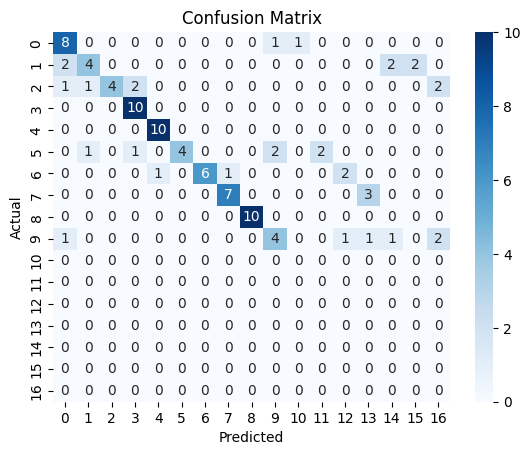

In [138]:
def evaluate_model_final(test_labels, pred_labels):
    '''
    This function is use to model evaluation.
    
    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.
    
    Output: None
    '''
    # Evaluate the model
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc
    
    # AUC-ROC
#     roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr') # .to_numpy().reshape(-1, 1)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
#     print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    

# Evaluate Model
y_train = unseen_result_df['act_vals'].values 
y_pred = unseen_result_df['unseen_pred_vals'].values 

evaluate_model_final(y_train, y_pred)

# FINAL PREDICTION PIPELINE 2

In [141]:
# # FINAL PREDICTION PIPELINE 2
def predict_image_nogen(image_path):
    vgg = load_model("vgg_model.h5")
    gen = load_model("generator.h5")

    with open("classifier.pkl", "rb") as f:
        clf = pickle.load(f)

    vgg_feat, glcm_feat = extract_features(image_path, vgg)

#     gen_feat = gen.predict([np.array([vgg_feat]), np.array([glcm_feat])])

    pred = clf.predict([vgg_feat])

    return pred

In [142]:
image_paths, image_names, act_lables, top_seen_labels, top_unseen_labels = [], [], [], [], []
pred_labels, act_vals, pred_vals = [], [], []


for i in glob.glob(os.path.join('awa_data', 'unseen', '*', '*')):
    image_path = i
    image_name = i.split('\\')[-1]
    act_lable = i.split('\\')[-2]
#     print(f"image_path : {image_path} \nimage_name : {image_name} \nact_lable : {act_lable}")
    
    pred_label = predict_image_nogen(image_path)[0]
#     print("pred_label : ", pred_label)
#     print(f"unseen_class_dict[act_lable] : {unseen_class_dict[act_lable]} \npred_label : {pred_label} \n")
    
    top_unseen_label = get_top_similar_classes_df(pred_label,
                            SentenceTransformer_model,
                            unseen_embeddings,
                            unseen_class_labels)[0]
#     print(top_unseen_label)
    
    image_paths.append(image_path) 
    image_names.append(image_name) 
    act_lables.append(act_lable)
    pred_labels.append(pred_label)
    act_vals.append(unseen_class_dict[act_lable])
    pred_vals.append(class_dict[pred_label])
    top_unseen_labels.append(top_unseen_label)
    
#     break

unseen_result_df = pd.DataFrame({
    'image_paths': image_paths,
    'image_names': image_names,
    'act_lables': act_lables,
    'pred_labels': pred_labels,
    'act_vals': act_vals,
    'pred_vals': pred_vals,
    'top_unseen_labels': top_unseen_labels
})
unseen_result_df.head()

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


...

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_unseen_labels
0,awa_data\unseen\chimpanzee\chimpanzee_10001.jpg,chimpanzee_10001.jpg,chimpanzee,monkey,0,8,"[chimpanzee, rat, leopard, raccoon, giant_panda]"
1,awa_data\unseen\chimpanzee\chimpanzee_10002.jpg,chimpanzee_10002.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."
2,awa_data\unseen\chimpanzee\chimpanzee_10003.jpg,chimpanzee_10003.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."
3,awa_data\unseen\chimpanzee\chimpanzee_10004.jpg,chimpanzee_10004.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."
4,awa_data\unseen\chimpanzee\chimpanzee_10005.jpg,chimpanzee_10005.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w..."


In [143]:
# Create new column
unseen_result_df['unseen_pred_vals'] = unseen_result_df.apply(
    lambda row: row['act_vals'] if row['act_lables'] in row['top_unseen_labels'] else row['pred_vals'],
    axis=1
)

# seen_result_df['seen_pred_vals'] = np.where(
#     seen_result_df.apply(lambda row: row['act_labels'] in row['top_seen_labels'], axis=1),
#     seen_result_df['act_vals'],
#     seen_result_df['pred_vals']
# )


unseen_result_df.head()

,image_paths,image_names,act_lables,pred_labels,act_vals,pred_vals,top_unseen_labels,unseen_pred_vals
0,awa_data\unseen\chimpanzee\chimpanzee_10001.jpg,chimpanzee_10001.jpg,chimpanzee,monkey,0,8,"[chimpanzee, rat, leopard, raccoon, giant_panda]",0
1,awa_data\unseen\chimpanzee\chimpanzee_10002.jpg,chimpanzee_10002.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0
2,awa_data\unseen\chimpanzee\chimpanzee_10003.jpg,chimpanzee_10003.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0
3,awa_data\unseen\chimpanzee\chimpanzee_10004.jpg,chimpanzee_10004.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0
4,awa_data\unseen\chimpanzee\chimpanzee_10005.jpg,chimpanzee_10005.jpg,chimpanzee,gorilla,0,5,"[chimpanzee, hippopotamus, raccoon, humpback_w...",0



MODEL EVALUATION
Accuracy: 65.00 %
Log Loss: 35.00 %
Cohen's Kappa Score: 62.00 %

classification_report:


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

              precision    recall  f1-score   support

           0       0.50      0.90      0.64        10
           1       0.00      0.00      0.00        10
           2       0.50      0.20      0.29        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      0.70      0.82        10
           6       1.00      0.70      0.82        10
           7       1.00      0.90      0.95        10
           8       0.91      1.00      0.95        10
           9       1.00      0.10      0.18        10
          10       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          17       0.00      0.00      0.00         0

    accuracy                           0.65       100
   macro avg       0.53      0.43      0.44       100
weighted avg       0.79   

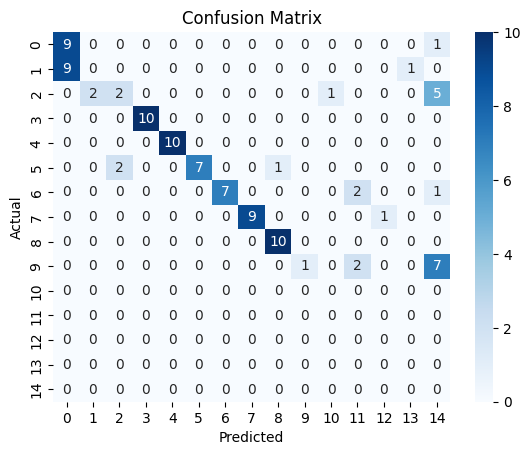

In [144]:
# Evaluate Model
y_train = unseen_result_df['act_vals'].values 
y_pred = unseen_result_df['unseen_pred_vals'].values 

evaluate_model_final(y_train, y_pred)